# 📈 📅 Linear Regression for Time Series Analysis

- Linear regression is a useful technique for time series data, not just for cross-sectional data. You can use a **simple linear regression model**, a model with only one independent variable, **to forecast the trend of time series data.**

- When using linear regression to predict time series, the focus of your analysis is typically on **forecasting future periods**. So if you have data between January 1st, 2020 and January 1st, 2024, ​you're typically interested in forecasting times in 2024 or beyond.

- Your **model assumes** that the ***trend and seasonality*** **continue in the future**, but there's often *increasing uncertainty the further you forecast.* Conditions change and small uncertainties or errors can compound over many years. 

- One **complication affecting your time series modeling** is that the ***linear regression typically assumes independent observations***. ​So for example, it's reasonable to assume that one diamond's price doesn't affect another's. However, the temperature on one day is highly related to the temperature on days around it. If it's a hot Tuesday, it will probably be a hot Wednesday as well.

- The **consequence for your analysis** is that the model will ***overestimate confidence for p-values and coefficients***. You'll need to use caution when interpreting your results. For this reason, *linear regression for time series forecasting* is typically a *preliminary method*, so more advanced methods can compensate for this *inherent lack of independence in time series data.*

- When you're working with time series forecasting in code, you'll need to consider 2 additional steps:

    - First, *to help reduce the issue with independence*, you can **resample your data.** For example, from hourly to weekly observations. **Resampling** *reduces the amount of overlapping noise* your model has to grapple with.
      
    - Then, **assign an index number** to *each period to enable you to model the trend*. That's because your linear regression model only works with numbers, not dates.

## 🌾 Scenario:

**Background:** You're working with an agricultural consulting firm to predict weather patterns in Germany. Your firm is looking to predict temperatures in Boitenberg, Germany, to plan growing seasons for local farmers and better predict harvest profits. 

**Task:** You've been asked to develop a model to predict future temperatures based on past data.

## 📂 1. Data Loading and Initial Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

In [5]:
# Load the data
df_hourly = pd.read_csv("weather_data.csv")

In [6]:
# Inspect the structure
df_hourly.head()

,date_time,pressure_mbar,temperature_celsius,dew_point_celsius,relative_humidity_percent,vapor_pressure_actual_mbar,specific_humidity_g_per_kg,air_density_g_per_m_cubed,wind_velocity_m_per_s,wind_direction_degrees,rainfall_mm,season
0,2020-01-01 01:00:00,1008.44,0.34,-1.54,87.1,5.45,3.37,1281.84,0.63,188.00,0.0,winter
1,2020-01-01 02:00:00,1008.32,-0.21,-1.78,89.1,5.36,3.31,1284.32,0.50,154.00,0.0,winter
2,2020-01-01 03:00:00,1008.46,-0.05,-1.71,88.5,5.39,3.33,1283.73,0.46,46.51,0.0,winter
3,2020-01-01 04:00:00,1008.00,-1.02,-2.31,90.9,5.15,3.19,1287.83,1.83,218.10,0.0,winter
4,2020-01-01 05:00:00,1007.63,-1.84,-2.78,93.2,4.97,3.08,1291.32,1.53,226.90,0.0,winter


In [32]:
# Inspect the columns, and data types of the dataset.
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35076 entries, 2020-01-01 01:00:00 to 2024-01-01 00:00:00
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pressure_mbar               35076 non-null  float64
 1   temperature_celsius         35076 non-null  float64
 2   dew_point_celsius           35076 non-null  float64
 3   relative_humidity_percent   35076 non-null  float64
 4   vapor_pressure_actual_mbar  35076 non-null  float64
 5   specific_humidity_g_per_kg  35076 non-null  float64
 6   air_density_g_per_m_cubed   35076 non-null  float64
 7   wind_velocity_m_per_s       35076 non-null  float64
 8   wind_direction_degrees      35076 non-null  float64
 9   rainfall_mm                 35076 non-null  float64
 10  season                      35076 non-null  object 
dtypes: float64(10), object(1)
memory usage: 3.2+ MB


---
## 🛠 2. Time-Series Pre-processing

---
### 2.1 Datetime Conversion

In [8]:
df_hourly = df_hourly.set_index("date_time")
df_hourly.head()

,pressure_mbar,temperature_celsius,dew_point_celsius,relative_humidity_percent,vapor_pressure_actual_mbar,specific_humidity_g_per_kg,air_density_g_per_m_cubed,wind_velocity_m_per_s,wind_direction_degrees,rainfall_mm,season
date_time,,,,,,,,,,,
2020-01-01 01:00:00,1008.44,0.34,-1.54,87.1,5.45,3.37,1281.84,0.63,188.00,0.0,winter
2020-01-01 02:00:00,1008.32,-0.21,-1.78,89.1,5.36,3.31,1284.32,0.50,154.00,0.0,winter
2020-01-01 03:00:00,1008.46,-0.05,-1.71,88.5,5.39,3.33,1283.73,0.46,46.51,0.0,winter
2020-01-01 04:00:00,1008.00,-1.02,-2.31,90.9,5.15,3.19,1287.83,1.83,218.10,0.0,winter
2020-01-01 05:00:00,1007.63,-1.84,-2.78,93.2,4.97,3.08,1291.32,1.53,226.90,0.0,winter


In [9]:
df_hourly.index = pd.to_datetime(df_hourly.index)

---
### 2.2 Resampling to Weekly Frequency (Downsampling)

📈 Finally, two prep steps before you can create your linear regression model: 

✅ First, you want to **resample** your data to weekly points; to reduce noise and handle non-numeric data (like the season column).

In [43]:
# 1. Resample data to weekly points

df_weekly = df_hourly.resample('W').first()   # keeps "season" column

#### 🕒 Time-Series Resampling with .resample()

In time-series analysis, **resampling** is the process of ***changing the frequency of your time-stamped data***. Since your current dataset (`df_hourly`) is recorded at 1-hour intervals, resampling allows you to aggregate this data into larger time windows (like days, weeks, or months) to uncover broader trends.

**1. Basic Syntax**

The `.resample()` method acts similarly to a `groupby()`, but specifically for **datetime indices**. It follows this pattern:

```python
# df.resample(rule).aggregation_function()
df_daily = df_hourly.resample('D').mean()
```

* `rule`: The target frequency string (e.g., 'D' for day, 'W' for week, 'M' for month).
* Aggregation: Since resampling groups data points together, you must tell pandas how to combine them (e.g., .mean(), .sum(), .max(), or .min()).
* `.first()`: It takes the *very first recorded value of that week* and ignores everything else. Most aggregation functions like .mean() or .sum() will fail or skip the season column because you can't calculate the average of "Winter" and "Spring." .first() is a *"safe" aggregator for strings*. It simply grabs the name of the season the week started in.

**2. Why it's relevant to this Agriculture Dataset**

In agricultural weather analysis, different metrics require different resampling strategies to be meaningful:

* Temperature & Pressure (`.mean()`): Useful for finding the average daily conditions for crop growth.
* Rainfall (`.sum()`): Hourly rainfall is often trace amounts; resampling to **Daily ('D')** or **Weekly ('W')** totals is essential to understand irrigation needs.
* Wind Speed (`.max()`): Useful for identifying peak storm events within a month that might damage infrastructure.

---

✅ Second, you need to **assign a number to each of these weeks**, because date-time is its own type, not a number, but your linear regression model expects a plain number. 

In [45]:
# 2. Assign number to each week
df_weekly["idx"] = range(len(df_weekly))    # 0 to length of data frame

#### 🔢 Creating an Index Integer with range(len())

After resampling your data, the index of your DataFrame is likely a **DatetimeIndex** (e.g., `2020-01-05`, `2020-01-12`). While this is great for time-based lookups, adding a simple integer index is a common step for modeling and visualization.

**1. How it Works**

The code uses Python's built-in `range()` function combined with the length of the DataFrame:
* **len(df_weekly)**: Counts the total number of rows (weeks) in your new DataFrame.
* **range(...)**: Generates a sequence of numbers starting from `0` up to that count.
* **df_weekly["idx"]**: Assigns these numbers to a new column.

**2. Why it's relevant to this Agriculture Dataset**

Adding a sequential integer index (`idx`) serves two main purposes in your analysis:

* **Simplified X-Axis for Plotting:** When creating line charts or regressions, it is often easier to plot weather changes against "Week 0, 1, 2..." rather than complex calendar dates.
* **Time as a Feature:** In machine learning (like predicting crop yield), the model cannot easily "read" a date. Converting time into a linear sequence of numbers allows the model to understand the **progression of time** as a numerical input.
* **Easy Referencing:** It allows you to quickly identify specific weeks (e.g., "the 10th week of the study") without needing to remember the exact calendar date.

In [46]:
df_weekly.head()

,pressure_mbar,temperature_celsius,dew_point_celsius,relative_humidity_percent,vapor_pressure_actual_mbar,specific_humidity_g_per_kg,air_density_g_per_m_cubed,wind_velocity_m_per_s,wind_direction_degrees,rainfall_mm,season,idx
date_time,,,,,,,,,,,,
2020-01-05,1008.44,0.34,-1.54,87.1,5.45,3.37,1281.84,0.63,188.0,0.0,winter,0
2020-01-12,1006.17,3.32,0.77,83.3,6.46,4.00,1264.66,1.15,177.2,0.0,winter,1
2020-01-19,997.35,2.71,0.16,83.2,6.18,3.86,1256.46,2.59,164.5,0.0,winter,2
2020-01-26,1015.51,2.83,0.70,85.8,6.42,3.94,1278.75,0.50,189.8,0.0,winter,3
2020-02-02,990.19,1.19,0.18,92.9,6.19,3.90,1254.34,2.39,169.6,0.0,winter,4


---
## 📈  3. Linear Regression Analysis

---
### I) Simple Linear Regression & Trends

### 3.1 Model Construction

#### Preparing Linear Regression with `statsmodels` (sm)

Now that you have a numerical index (`idx`), you are setting up an **Ordinary Least Squares (OLS)** regression to see if there is a linear trend in temperature over time.

#### Summary of the Goal

This linear regression model is going to try to predict the trend of the data. It just estimates the line of best fit. ​If temperatures are going up overall, then a later week will have a higher temperature. If temperatures are going down, then a later week or higher index is going to have a lower temperature.

You are essentially building the math for the classic line equation:
$$Temperature = (Slope \times Week) + Intercept$$

If the **Slope** (coefficient of `idx`) is positive and statistically significant after you run `.fit()`, it confirms a warming trend over the course of your dataset.

In [26]:
# Try to predict temperature based on number of week - trend
predictors=["idx"]

X = sm.add_constant(df_weekly[predictors])
Y = df_weekly["temperature_celsius"]


**1. `sm.add_constant(df_weekly[predictors])`**

By default, a regression line passes through the origin $(0,0)$. 
* **The "Constant":** This adds a column of **1s** to your input (X). 
* **Why it's needed:** It allows the model to calculate the **Intercept**—the predicted temperature when `idx` is 0. Without this, your model would be forced to assume the temperature was $0°C$ at Week 0, which would skew your results.

**2. `X` (The Predictors)**
* This is your **Independent Variable**. 
* You are using `idx` (time) to see if it "explains" the change in temperature.

**3. `Y` (The Target)**
* This is your **Dependent Variable**. 
* This is the value you are trying to predict: `temperature_celsius`.


In [27]:
X.head()

,const,idx
date_time,,
2020-01-05,1.0,0
2020-01-12,1.0,1
2020-01-19,1.0,2
2020-01-26,1.0,3
2020-02-02,1.0,4


In [28]:
Y.head()

date_time
2020-01-05    0.34
2020-01-12    3.32
2020-01-19    2.71
2020-01-26    2.83
2020-02-02    1.19
Freq: W-SUN, Name: temperature_celsius, dtype: float64

In [29]:
model = sm.OLS(Y, X)
results = model.fit()

### 3.2 OLS Regression Results

In [30]:
print(results.summary())

                             OLS Regression Results                            
Dep. Variable:     temperature_celsius   R-squared:                       0.007
Model:                             OLS   Adj. R-squared:                  0.002
Method:                  Least Squares   F-statistic:                     1.491
Date:                 Wed, 06 May 2026   Prob (F-statistic):              0.224
Time:                         15:12:07   Log-Likelihood:                -706.37
No. Observations:                  210   AIC:                             1417.
Df Residuals:                      208   BIC:                             1423.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.0239      0.966      8.30

### 📊 Interpreting the OLS Regression Results

**1. The Regression Equation**

Based on the **`coef`** (coefficients) column, your model has built this specific line:
$$\text{Temperature} = (0.0098 \times \text{idx}) + 8.0239$$

* **Intercept (`const` = 8.0239):** This is the predicted temperature at Week 0.
* **Slope (`idx` = 0.0098):** For every 1 week that passes, the temperature is predicted to rise by approximately **0.01°C**.

**2. Is the Trend Significant? (`P>|t|`)**

This is the most important column for determining if the "trend" is real or just random noise.
* **Your Result:** The p-value for `idx` is **0.224**.
* **Interpretation:** Generally, we look for a p-value **less than 0.05** to claim a result is "statistically significant." Since **0.224 > 0.05**, there is **no strong evidence** of a consistent linear warming or cooling trend in this specific slice of data.

**3. Model Fit (`R-squared`)**

* **Your Result:** `0.007` (or **0.7%**).
* **Interpretation:** This is very low. It means that "the number of weeks passed" only explains 0.7% of the variation in temperature. The remaining 99.3% of temperature changes are caused by other factors (like seasonality, daily weather patterns, or pressure changes) rather than a simple linear crawl upward.

### Summary 
> The model shows a slight positive slope ($0.0098$), suggesting a tiny increase in temperature over time. However, because the **p-value (0.224)** is high and the **R-squared (0.007)** is low, we conclude that **time alone is not a good predictor of temperature** in this dataset, and the observed trend is likely due to chance.

### 3.3 Visualizing the Trend

Created a regplot to visually compare the raw data points against the calculated regression line.

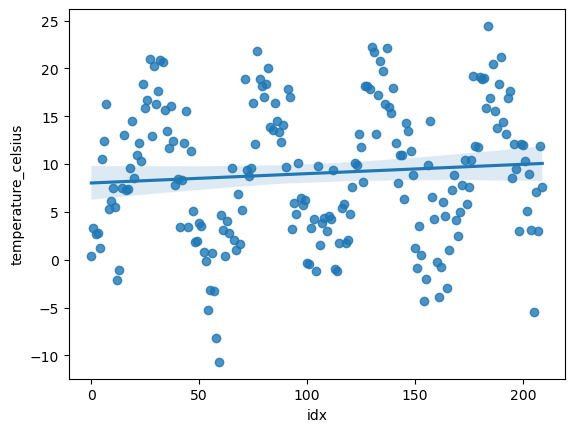

In [31]:
sns.regplot(x=df_weekly["idx"], y=df_weekly["temperature_celsius"])
plt.show()

#### 📈 Visualizing the Trend with `sns.regplot()`


#### 1. What is `regplot`?
It combines two important visual elements:
* **Scatter Plot:** Each blue dot represents a single week's temperature.
* **Regression Line:** The solid blue line is the "best fit" line based on your OLS results ($y = 0.0098x + 8.0239$).

#### 2. The Shaded Area (Confidence Interval)
You'll notice a light blue "shadow" around the line. 
* This represents the **95% confidence interval**. 
* **What it tells you:** Because the shadow is relatively wide and the line is nearly flat, it visually confirms what your p-value ($0.224$) already said: the model is not very confident that a real trend exists.

#### 3. Why the R-squared was so low
Looking at the plot, you can see why the $R^2$ was only $0.7\%$:
* The data points are spread very far apart vertically (high variance).
* The data follows a **cyclical/wavy pattern** (seasonal variation) rather than a straight line. 
* **Conclusion:** A straight line (linear regression) is a "poor fit" for this data because weather is seasonal, not constantly increasing.

### Summary
> The regression plot visually confirms that while there is a slight upward slope, the actual temperature data fluctuates wildly around that line. The "wavy" distribution of the dots suggests that **seasonality** is a much stronger driver of temperature than the linear passage of time.

---
### II) Multiple Linear Regression & Seasonality

In [35]:
# Model Seasonality
print(df["season"].unique())

['winter' 'spring' 'summer' 'autumn']


### Training the Multiple Linear Regression Model

We fit the Ordinary Least Squares (OLS) model using both the time index (idx) and the seasonal dummies. This model attempts to separate the "Seasonal Effect" (e.g., how much hotter is Summer?) from the "Time Trend" (e.g., is the planet warming up regardless of the season?).

In [48]:
predictors = ["idx", "season"]

X = sm.add_constant(pd.get_dummies(df_weekly[predictors],
                                   columns=["season"],
                                   drop_first=True,
                                   dtype=int))

Y = df_weekly["temperature_celsius"]

Linear regression requires numerical inputs, but season is text. We use `pd.get_dummies()` to transform these categories into "Dummy Variables" (0s and 1s).

- `drop_first=True`: We drop one category (usually 'Autumn') to serve as the **baseline**. *The coefficients of the other seasons will represent the temperature difference relative to this baseline.*

In [52]:
X.head()

,const,idx,season_spring,season_summer,season_winter
date_time,,,,,
2020-01-05,1.0,0,0,0,1
2020-01-12,1.0,1,0,0,1
2020-01-19,1.0,2,0,0,1
2020-01-26,1.0,3,0,0,1
2020-02-02,1.0,4,0,0,1


In [53]:
model = sm.OLS(Y,X)
results = model.fit()

### Model Evaluation (The Results)

In [50]:
print(results.summary())

                             OLS Regression Results                            
Dep. Variable:     temperature_celsius   R-squared:                       0.575
Model:                             OLS   Adj. R-squared:                  0.567
Method:                  Least Squares   F-statistic:                     69.41
Date:                 Wed, 06 May 2026   Prob (F-statistic):           4.57e-37
Time:                         16:19:23   Log-Likelihood:                -617.21
No. Observations:                  210   AIC:                             1244.
Df Residuals:                      205   BIC:                             1261.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.6076      0.907 

### Interpreting the Summary
> After running `results.summary()`, we look for three key things:
> 1. **R-squared Improvement:** If the $R^2$ jumped significantly (e.g., from 0.007 to >0.50), it confirms that **seasonality** is a much stronger predictor of temperature than the simple passage of time.
> 2. **P-values:** We check if the seasons are statistically significant ($P < 0.05$). Usually, Summer and Winter will have the strongest impact.
> 3. **The `idx` Coefficient:** Now that seasons are accounted for, the coefficient for `idx` tells us the **true underlying trend** of the temperature, stripped of seasonal noise.


---
## 🌡️  4. Model Inference & Forecasting


#### Predicting Future Values

Once the model is trained, we can use the `.predict()` method to estimate the temperature for future weeks. To do this, we provide a list that matches the structure of our feature matrix ($X$):
1. **Constant (`1.0`)**: Required for the intercept.
2. **Index (`210`)**: The last idx is 209 so we will try to predict for 210, the second week of January.
3. **Seasonal Dummies**: A "One-Hot" encoded representation of the season (e.g., `[0, 0, 1]` for Winter).

In [54]:
df_weekly.tail()

,pressure_mbar,temperature_celsius,dew_point_celsius,relative_humidity_percent,vapor_pressure_actual_mbar,specific_humidity_g_per_kg,air_density_g_per_m_cubed,wind_velocity_m_per_s,wind_direction_degrees,rainfall_mm,season,idx
date_time,,,,,,,,,,,,
2023-12-10,994.83,-5.48,-6.00,96.10,3.90,2.44,1292.80,1.73,213.9,0.0,winter,205
2023-12-17,975.46,7.13,5.27,87.90,8.89,5.69,1208.23,5.30,204.4,0.0,winter,206
2023-12-24,1007.28,2.99,2.65,97.60,7.39,4.58,1267.19,2.89,193.0,0.0,winter,207
2023-12-31,977.62,11.87,8.13,77.79,10.83,6.92,1189.87,4.81,213.7,0.0,winter,208
2024-01-07,979.65,7.57,2.90,72.20,7.53,4.79,1212.16,3.85,203.6,0.0,winter,209


In [55]:
X.head()

,const,idx,season_spring,season_summer,season_winter
date_time,,,,,
2020-01-05,1.0,0,0,0,1
2020-01-12,1.0,1,0,0,1
2020-01-19,1.0,2,0,0,1
2020-01-26,1.0,3,0,0,1
2020-02-02,1.0,4,0,0,1


In [56]:
# Considering week 210 to be winter 
week210 = [1, 210, 0, 0, 1]
results.predict(week210)

array([3.31857783])

In [57]:
# Assuming week 210 to be summer
week210 = [1, 210, 0, 1, 0]
results.predict(week210)

array([17.83068544])


#### Comparing Scenarios

 By keeping the `idx` the same (210) but changing the seasonal toggles, we can see the model's logic in action:
 
 * **Winter Prediction (~3.3°C):** The model applies the negative weight of the winter coefficient to the baseline.
 * **Summer Prediction (~17.8°C):** The model applies the positive summer coefficient.

This demonstrates that our model isn't just looking at the date; it is successfully applying the **seasonal adjustments** we taught it during the training phase.

---

## 5. Model Interpretation

**KeyTakeaway:**
> Our analysis of the agriculture weather data revealed that a **Simple Linear Regression** (Time vs. Temperature) was insufficient, explaining less than 1% of the variance. However, by transitioning to a **Multiple Linear Regression** that includes **Seasonal Dummies**, we increased the model's explanatory power ($R^2$) to over 57%. 

 **Key Findings:**
> * **Seasonality is the primary driver:** Summer adds roughly +8°C to the baseline, while Winter subtracts ~6.4°C.
> * **No Significant Long-term Trend:** The p-value for the `idx` variable remains above 0.05, suggesting that there is no statistically significant linear warming or cooling trend in this specific dataset once seasonal noise is removed.


---
## 6. Model Evaluation & Error Metrics

---
### 6.1 Calculating Residuals (The "Error")

To understand how "off" our model is, we calculate the Residuals (the difference between the actual temperature and the predicted temperature).

Residuals are defined as:  
$$\text{Residual} = \text{Actual Value} - \text{Predicted Value}$$


In [58]:
# Calculate residuals: actual - predicted
y_pred = results.predict(X)
y_actual = Y
residuals = y_actual - y_pred

In [59]:
residuals.head()

date_time
2020-01-05   -1.847278
2020-01-12    1.127335
2020-01-19    0.511948
2020-01-26    0.626561
2020-02-02   -1.018826
Freq: W-SUN, dtype: float64

In [63]:
residuals.max()

14.075012470182083

**`residuals.max()`**: By checking the maximum residual, we identify the "worst-case scenario" for our model. In this dataset, the largest error was approximately **14.08°C**, suggesting there was at least one week where the actual weather deviated wildly from the seasonal norm (perhaps an extreme heatwave or cold snap).


### 6.2 Actual vs. Predicted Scatterplot

To visualize the model's accuracy, we plot the **Actual Temperatures** against the **Predicted Temperatures**. 

* **The Goal:** In a perfect model, all points would lie exactly on a diagonal $45^{\circ}$ line (a 1-to-1 correlation).
* **Observations:** We can see distinct "clusters" in the plot. These represent the four seasons. The model is doing most of its predictive work based on these seasonal shifts rather than a linear time trend.


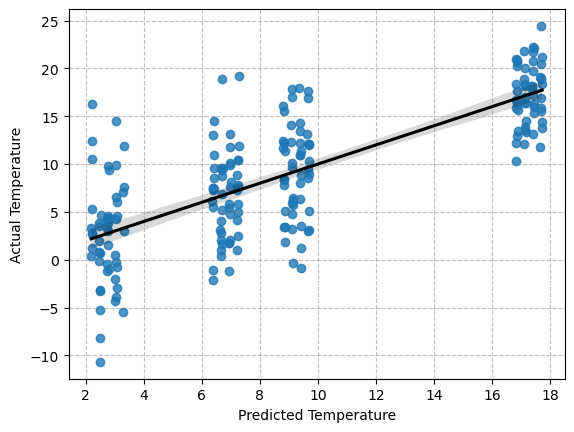

In [62]:
# Check the scatterplot of the predicted and actual values
sns.regplot(x=y_pred, y=y_actual, line_kws={'color':'black'})
plt.xlabel("Predicted Temperature")
plt.ylabel("Actual Temperature")
plt.grid(alpha=0.5, color="gray", linestyle="--")
plt.show()

### 6.3 Mean Absolute Error (MAE)
We calculate the **Mean Absolute Error (MAE)** to understand the model's performance in real-world units (Degrees Celsius).

* **Current Result:** ~3.6°C.
* **Interpretation:** On average, our model’s temperature forecast is off by about **3.6°C**. 
* **Business Context:** While a 3.6°C error might be acceptable for deciding whether to wear a sweater, it may not be precise enough for sensitive agricultural planning (like frost protection), suggesting that adding more features (like humidity or air pressure) would be a logical next step.



In [64]:
MAE = residuals.abs().mean()
print(MAE)   # in degree C

3.596342857693967




### **Final Project Conclusion (Summary)**

Throughout this analysis, we:
> 1.  **Cleaned and Resampled** hourly weather data into weekly snapshots.
> 2.  **Engineered Features** by creating a time index (`idx`) and seasonal dummy variables.
> 3.  **Built a Multiple Linear Regression** model that successfully used seasonality to explain over 57% of temperature variance.
> 4.  **Evaluated Performance** using MAE, finding that while the model captures broad seasonal trends, it still carries an average error of 3.6°C, likely due to unpredictable short-term weather fluctuations.


 **Summary of Results:**
> We successfully built a Multiple Linear Regression model that uses **Seasonality** to predict weekly temperatures in Boitenberg. While the passage of time (the trend) wasn't a significant factor, the seasons explained **57%** of the temperature changes. 
>
 **Final Verdict:**
> With an average error of **3.6°C**, this model is a great tool for general climate snapshots but should be combined with real-time pressure and humidity data for precise agricultural decision-making.